## Building the Allegheny County polluter point dataset


2. **Download the TRI file**
   - Source: EPA TRI Basic Data Files page (epa.gov/toxics-release-inventory-tri-program)
   - Select your year and Pennsylvania, then download the CSV.
   - Also download the "Guide to Using the TRI Basic Data Files" PDF. Column names include number prefixes that have changed across years.
   - Each row is one facility-chemical combination, not one facility.

7. **Build and check geometry**
   - Create point geometry from longitude (x) and latitude (y), in that order.
   - Set CRS to EPSG:4326, then reproject to EPSG:2272.
   - Plot over the Allegheny County boundary: every point should fall inside the county, and Clairton should land on the river in Clairton.
   - Fix or drop facilities with missing or wrong coordinates, and document it.

8. **Save and hand off**
   - Save as GeoPackage or GeoJSON in EPSG:2272.
   - Columns: facility ID, name, city, parent company, total air (lbs), RSEI Score, RSEI Hazard, rank, top-10 flag, U.S. Steel flag.
   - Record the year, selection rule, and join results for the report's data section.

## Step 1: Get the Allegheny County shapefile

In [1]:
# import allegheny county shapefile from census python package
from dotenv import load_dotenv
import os
import census as c
from us import states
import pygris
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# load_dotenv()
# API_KEY = os.getenv("CENSUS_API_KEY")

# alleg = pygris.counties(states.PA.fips).query("NAME == 'Allegheny'").to_crs("EPSG:2272")

# # save alleg as geojson to disk
# alleg.to_file("alleg.geojson", driver="GeoJSON")

# load allegh from geojson file
alleg = gpd.read_file("alleg.geojson")

## Step 2: Process the TRI and RSEI data, select the most polluting facilities

### 2.1 TRI data

In [2]:
tri_basic=pd.read_csv("tri_2024_pa.csv")
# allegh=tri_basic[tri_basic['7. COUNTY']=='ALLEGHENY']

tri_allegh=(
    tri_basic
    .query("`7. COUNTY` == 'ALLEGHENY'")
    .filter(items=[
        "2. TRIFD", "4. FACILITY NAME", "5. STREET ADDRESS", "6. CITY",
        "12. LATITUDE", "13. LONGITUDE", "15. PARENT CO NAME",
        "50. UNIT OF MEASURE", "51. 5.1 - FUGITIVE AIR", "52. 5.2 - STACK AIR"
    ])
    .set_axis(["trifd", "name", "address", "city", "lat", "lon", "parent",
               "unit", "fugitive_air", "stack_air"], axis=1)
    .query("unit == 'Pounds'")
    .assign(air_lbs=lambda d: d["fugitive_air"].fillna(0) + d["stack_air"].fillna(0))
    .groupby("trifd").agg(
        name=("name", "first"),
        address=("address", "first"),
        city=("city", "first"),
        parent=("parent", "first"),
        lat=("lat", "first"),
        lon=("lon", "first"),
        air_lbs=("air_lbs", "sum"),
    )
    .reset_index()
    .sort_values("air_lbs", 
                 ascending=False)
    .reset_index(drop=True)
    .assign(tri_rank=lambda d: d.index + 1)
)
tri_allegh

,trifd,name,address,city,parent,lat,lon,air_lbs,tri_rank
0,15025SSCLR400ST,USS-CLAIRTON PLANT,400 STATE ST MS 71,CLAIRTON,US STEEL CORP,40.294941,-79.874537,775872.720,1
1,15104SSDGRBRADD,USS MON VALLEY WORKS - EDGAR THOMSON PLANT,BRADDOCK AVE & 13TH ST,BRADDOCK,US STEEL CORP,40.397262,-79.859713,96883.690,2
2,15034SSRVNPOBOX,USS MON VALLEY WORKS - IRVIN PLANT,CAMP HOLLOW RD,WEST MIFFLIN,US STEEL CORP,40.340524,-79.914952,73871.600,3
3,15088HRCLSSTATE,SYNTHOMER JEFFERSON HILLS LLC,2200 STATE HWY 837,JEFFERSON HILLS,YULE CATTO INC.,40.267336,-79.903751,50394.000,4
4,15122LBRTY1575L,LIBERTY PULTRUSIONS,1575 LEBANON SCHOOL RD,WEST MIFFLIN,NaN,40.338887,-79.899186,28824.910,5
5,15104MSDVT13BRA,TMS INTERNATIONAL LLC,1300 BRADDOCK AVE,BRADDOCK,TMS INTERNATIONAL CORP,40.397191,-79.859663,27877.980,6
6,15144PPGND125CO,PPG INDUSTRIESINC-SPRINGDALE COMPLEX,125 COLFAX ST,SPRINGDALE,PPG INDUSTRIES INC,40.537373,-79.784005,22186.090,7
7,15225NVLLC2800N,NEVILLE CHEMICAL CO,2800 NEVILLE RD,PITTSBURGH,NaN,40.500626,-80.098238,14392.000,8
8,15225SHLND2650N,INEOS COMPOSITES US LLC,2650 NEVILLE RD,PITTSBURGH,INEOS ENTERPRISES US HOLDCO LLC,40.497715,-80.091249,13776.000,9
9,15225CLGNC200NE,CALGON CARBON CORP NEVILLE ISLAND PLANT,200 NEVILLE RD,PITTSBURGH,KURARAY HOLDINGS USA INC,40.492203,-80.079813,6999.000,10


Let's take a look at the distribution of the relevant TRI variable, `air_lbs`, which is the total pounds of air emissions reported by each facility. We'll use a histogram to visualize the distribution of this variable.

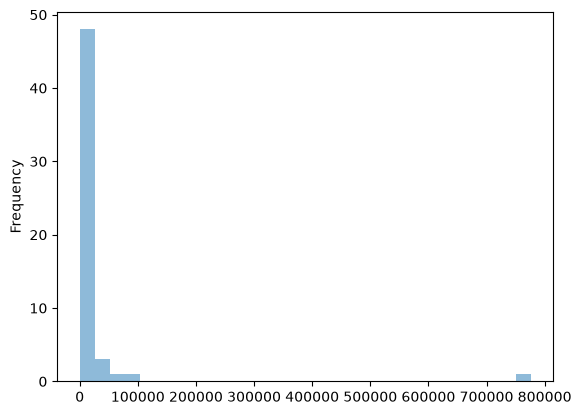

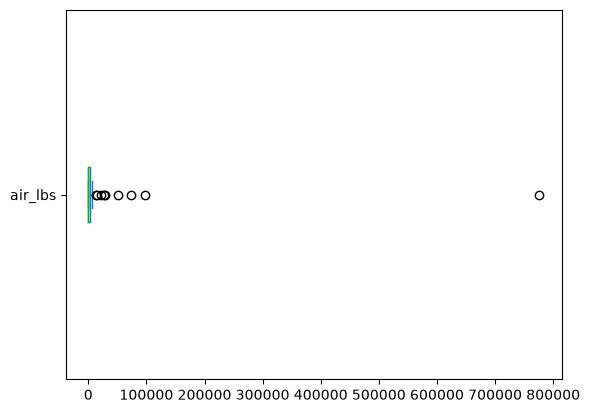

In [3]:
# first plot: basic histogram and boxplot of TRI pounds, side-by-side
tri_allegh[['air_lbs']].plot(kind='hist', bins=30, alpha=0.5, legend=False)
tri_allegh[['air_lbs']].plot(kind='box', vert=False, legend=False)
plt.show()

It looks like there's one facility that reports a very high amount of air emissions, which is skewing the distribution. To get a better sense of the distribution of the other facilities, we can remove this outlier and plot the histogram again.

In [ ]:
# identify outlier for air_lbs
outlier = tri_allegh['air_lbs'].max()
tri_allegh[tri_allegh['air_lbs'] == outlier][["name", "city", "air_lbs"]]


,name,city,air_lbs
0,USS-CLAIRTON PLANT,CLAIRTON,775872.72


The USS Clairton Plant is the facility with far and away the highest reported air emissions. We definitely want it in our analysis, but let's look at the rest of the facilities without it to get a better sense of the distribution of air emissions.

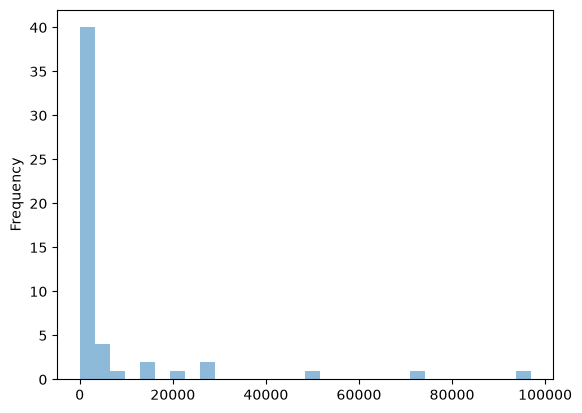

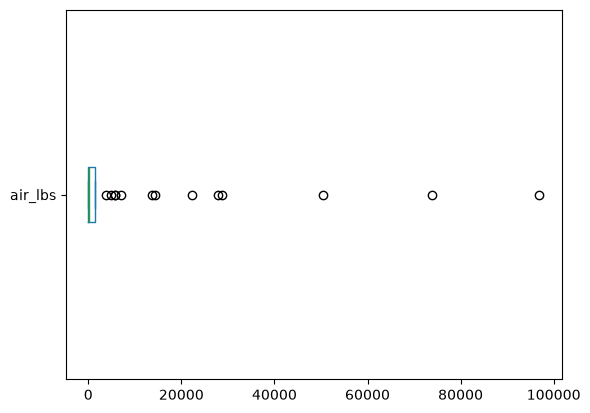

In [5]:
# histogram and boxplot of TRI pounds with outlier removed
tri_allegh_no_outlier = tri_allegh[tri_allegh['air_lbs'] != outlier]
tri_allegh_no_outlier[['air_lbs']].plot(kind='hist', bins=30, alpha=0.5, legend=False)
tri_allegh_no_outlier[['air_lbs']].plot(kind='box', vert=False, legend=False)
plt.show()

There's still definitely a concentration around 0, but the distribution is more spread out than before. The boxplot shows that there are a few facilities with relatively high emissions, but not nearly as extreme as the USS Clairton Plant. We'll want to identify the outliers in this distribution as the top facilities in our analysis. 

### 2.2 RSEI data

In [6]:
easyrsei = (
    pd.read_excel("easyrsei_2022_air.xlsx")
    .rename(
        columns={
            "Facility Name": "name",
            "Street": "address",
            "RSEI Score": "rsei_score"
        })
    .filter(items=[
        "name", "address", "rsei_score"]
        )
    .assign(rsei_rank=lambda d: d["rsei_score"].rank(ascending=False, method="min"))
)
easyrsei

,name,address,rsei_score,rsei_rank
0,WABTEC COMPONENTS LLC FORMERLY THERMAL TRANSFE...,50 N LINDEN ST,250145.632729,1.0
1,USS-CLAIRTON PLANT,400 STATE ST MS 71,83152.966207,2.0
2,PPG INDUSTRIESINC-SPRINGDALE COMPLEX,125 COLFAX ST,77704.927905,3.0
3,UNIVERSAL STAINLESS & ALLOY PRODUCTS INC,600 MAYER ST,47409.307944,4.0
4,TMS INTERNATIONAL LLC,1300 BRADDOCK AVE,36569.940431,5.0
5,MCCONWAY & TORLEY LLC PLT 1801,109 48TH ST,12867.228911,6.0
6,ATI FLAT ROLLED PRODUCTS HOLDINGS LLC,100 RIVER RD,12838.631711,7.0
7,NEVILLE CHEMICAL CO,2800 NEVILLE RD,7843.502919,8.0
8,USS MON VALLEY WORKS - EDGAR THOMSON PLANT,BRADDOCK AVE & 13TH ST,5536.456060,9.0
9,ATI POWDER METALS - OAKDALE,1001 ROBB HILL RD,3217.501600,10.0


Similar to the TRI data, we can look at the distribution of the RSEI score variable, `rsei_score`. We'll use a histogram to visualize the distribution of this variable.

<Axes: >

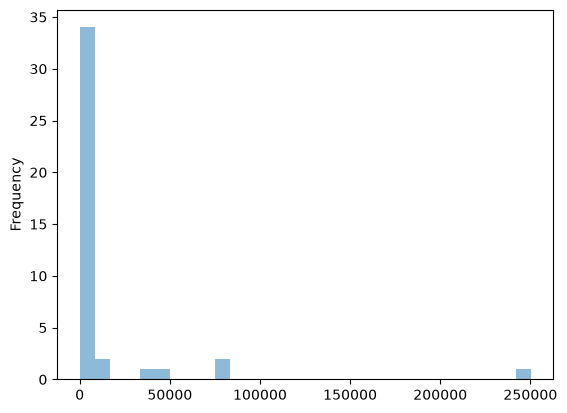

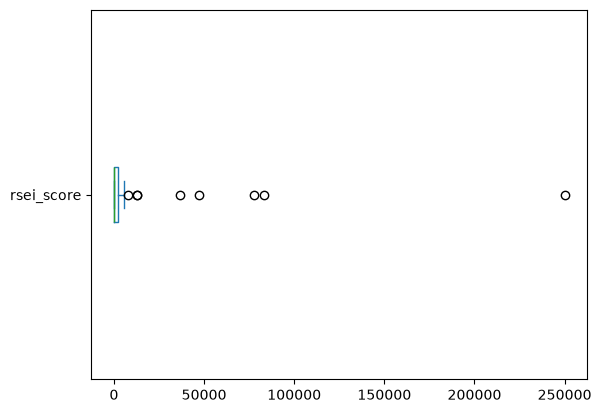

In [7]:
easyrsei[['rsei_score']].plot(kind='hist', bins=30, alpha=0.5, legend=False)
easyrsei[['rsei_score']].plot(kind='box', vert=False, legend=False)

The distribution for RSEI score is more spread out than the TRI air emissions distribution, with a few facilities having relatively high RSEI scores. We'll want to identify the outliers in this distribution as well, as they represent the facilities with the highest potential risk to human health and the environment.

In [8]:
# identify outlier for rsei_score
outlier_rsei = easyrsei['rsei_score'].nlargest(3).index
# print df of 3 largest rsei_score names and values
easyrsei.loc[outlier_rsei, ["name", "rsei_score"]]

,name,rsei_score
0,WABTEC COMPONENTS LLC FORMERLY THERMAL TRANSFE...,250145.632729
1,USS-CLAIRTON PLANT,83152.966207
2,PPG INDUSTRIESINC-SPRINGDALE COMPLEX,77704.927905


USS Clairton shows up again hear, along with two ATI facilities. These three facilities are the top three in terms of RSEI score, and we'll want to include them in our analysis as well.

### 2.3 Combine TRI and RSEI data

Because the RSEI and the TRI datasets reflect different measures that are both relevant to the question of which facilities are the most polluting, we'll want to include the top facilities from both datasets in our analysis. While there's a number of different ways of doing this, we'll use the `mapclassify` package to classify the facilities into groups using the Jenks natural breaks method. This method identifies natural groupings in the data, and we'll use it to identify the top facilities in both datasets. 

In [ ]:
import mapclassify as mc
import numpy as np

def top_class(values, k):
    """True for rows in the highest Jenks class (log10 scale). Zeros are never top."""
    out = pd.Series(False, index=values.index)
    pos = values[values > 0]
    jenks = mc.FisherJenks(np.log10(pos), k=k)
    out[pos.index] = jenks.yb == k - 1
    return out
 
tri_allegh["tri_top"] = top_class(tri_allegh["air_lbs"], k=5)
easyrsei["rsei_top"] = top_class(easyrsei["rsei_score"], k=4)

/var/folders/92/rrvsc6_x7slf490khsx_xn2c0000gn/T/ipykernel_63858/760923391.py:12: UserWarning: Numba not installed. Using slow pure python version.
  tri_allegh["tri_top"] = top_class(tri_allegh["air_lbs"], k=5)
/var/folders/92/rrvsc6_x7slf490khsx_xn2c0000gn/T/ipykernel_63858/760923391.py:13: UserWarning: Numba not installed. Using slow pure python version.
  easyrsei["rsei_top"] = top_class(easyrsei["rsei_score"], k=4)


The main parameter to decide on when creating natural breaks is the number of classes. After consulting literature (mostly Google), we checked two through seven classes for each measure using goodness of variance fit (GVF), the standard diagnostic for Jenks. GVF runs from 0 to 1 and measures how much of the variation the classes capture.

In [ ]:
def gvf(values, k):
    """Goodness of variance fit and top-class size for k Jenks classes on log10 values."""
    v = np.log10(values[values > 0])
    jenks = mc.FisherJenks(v, k=k)
    sdam = ((v - v.mean()) ** 2).sum()
    sdcm = sum(((v[jenks.yb == c] - v[jenks.yb == c].mean()) ** 2).sum() for c in range(k))
    return 1 - sdcm / sdam, int((jenks.yb == k - 1).sum())

rows = []
for label, s in [("TRI air lbs", tri_allegh["air_lbs"]), ("RSEI score", easyrsei["rsei_score"])]:
    for k in range(2, 8):
        fit, n_top = gvf(s, k)
        rows.append({"measure": label, "k": k, "gvf": round(fit, 2), "top_class_n": n_top})

pd.DataFrame(rows).pivot(index="k", columns="measure")

We determined the number of classes for each measure using the GVF diagnostic and the stability of the top class. For TRI, the GVF measure shows that happening at five classes, and for RSEI at four. Both settings have a GVF above 0.9 (0.96 for TRI and 0.92 for RSEI), meaning The TRI result is the shakier of the two. Because the next smallest group made the TRI top class jump to 13 facilities, which we thought represented too many, we opted for 5 groups. In the end this is a judgment call, and we'd rather state the rule than pretend the data picked it for us.

The union gives us 11 facilities. Only Clairton and Edgar Thomson are in both top classes. We matched the two files on standardized street address and checked that every RSEI top-class facility found a TRI match.

In [10]:
# Standardize addresses so the join isn't thrown off by spacing or capitalization
for df in (tri_allegh, easyrsei):
    df["address"] = df["address"].str.strip().str.upper()

major_fac = (
    tri_allegh
    .merge(easyrsei.rename(columns={"name": "rsei_name"}),
           on="address", how="left", validate="one_to_one")
    .assign(rsei_top=lambda d: d["rsei_top"].fillna(False).astype(bool),
            major=lambda d: d["tri_top"] | d["rsei_top"])
    .query("major")
    .sort_values("air_lbs", ascending=False)
    .reset_index(drop=True)
)

# Stop if any RSEI top facility failed to match a TRI facility
unmatched = easyrsei.loc[easyrsei["rsei_top"] & ~easyrsei["address"].isin(tri_allegh["address"]), "name"]
assert unmatched.empty, f"RSEI top facilities with no TRI match: {unmatched.tolist()}"

major_fac

,trifd,name,address,city,parent,lat,lon,air_lbs,tri_rank,tri_top,rsei_name,rsei_score,rsei_rank,rsei_top,major
0,15025SSCLR400ST,USS-CLAIRTON PLANT,400 STATE ST MS 71,CLAIRTON,US STEEL CORP,40.294941,-79.874537,775872.72,1,True,USS-CLAIRTON PLANT,83152.966207,2.0,True,True
1,15104SSDGRBRADD,USS MON VALLEY WORKS - EDGAR THOMSON PLANT,BRADDOCK AVE & 13TH ST,BRADDOCK,US STEEL CORP,40.397262,-79.859713,96883.69,2,True,USS MON VALLEY WORKS - EDGAR THOMSON PLANT,5536.456060,9.0,True,True
2,15034SSRVNPOBOX,USS MON VALLEY WORKS - IRVIN PLANT,CAMP HOLLOW RD,WEST MIFFLIN,US STEEL CORP,40.340524,-79.914952,73871.60,3,True,USS MON VALLEY WORKS - IRVIN PLANT,552.693876,17.0,False,True
3,15088HRCLSSTATE,SYNTHOMER JEFFERSON HILLS LLC,2200 STATE HWY 837,JEFFERSON HILLS,YULE CATTO INC.,40.267336,-79.903751,50394.00,4,True,SYNTHOMER JEFFERSON HILLS LLC,32.298782,22.0,False,True
4,15104MSDVT13BRA,TMS INTERNATIONAL LLC,1300 BRADDOCK AVE,BRADDOCK,TMS INTERNATIONAL CORP,40.397191,-79.859663,27877.98,6,False,TMS INTERNATIONAL LLC,36569.940431,5.0,True,True
5,15144PPGND125CO,PPG INDUSTRIESINC-SPRINGDALE COMPLEX,125 COLFAX ST,SPRINGDALE,PPG INDUSTRIES INC,40.537373,-79.784005,22186.09,7,False,PPG INDUSTRIESINC-SPRINGDALE COMPLEX,77704.927905,3.0,True,True
6,15225NVLLC2800N,NEVILLE CHEMICAL CO,2800 NEVILLE RD,PITTSBURGH,NaN,40.500626,-80.098238,14392.00,8,False,NEVILLE CHEMICAL CO,7843.502919,8.0,True,True
7,15014LLGHNRIVER,ATI FLAT ROLLED PRODUCTS HOLDINGS LLC,100 RIVER RD,BRACKENRIDGE,ATI INC,40.603477,-79.736813,1419.00,15,False,ATI FLAT ROLLED PRODUCTS HOLDINGS LLC,12838.631711,7.0,True,True
8,15017CYTMPMAYER,UNIVERSAL STAINLESS & ALLOY PRODUCTS INC,600 MAYER ST,BRIDGEVILLE,UNIVERSAL STAINLESS & ALLOY PRODUCTS INC,40.366381,-80.100483,488.00,24,False,UNIVERSAL STAINLESS & ALLOY PRODUCTS INC,47409.307944,4.0,True,True
9,1511WTHRML5NRTH,WABTEC COMPONENTS LLC FORMERLY THERMAL TRANSFE...,50 N LINDEN ST,DUQUESNE,WABTEC CORP,40.378014,-79.848866,260.00,25,False,WABTEC COMPONENTS LLC FORMERLY THERMAL TRANSFE...,250145.632729,1.0,True,True


In [12]:
import geopandas as gpd
fac_gpd = gpd.GeoDataFrame(major_fac, geometry=gpd.points_from_xy(major_fac["lon"], major_fac["lat"]),
                       crs="EPSG:4326").to_crs("EPSG:2272")

## Step 3: Produce map of Allegheny County polluters 

In [ ]:
alleg_outline = alleg.explore(fill=False)

# create log scale choropleth map of air release pounds for major facilities in Allegheny County

fac_gpd["log_air_lbs"] = np.log10(fac_gpd["air_lbs"].replace(0, np.nan))

fac_gpd.explore(
    column="log_air_lbs", 
    cmap="Reds", 
    legend=True, 
    marker_kwds={"radius": 5}, 
    opacity=0.9, 
    m=alleg_outline
    )

In [17]:
# save point locations as geojson
fac_gpd.to_file("major_fac.geojson", driver="GeoJSON")